# 机器学习实验一：bank 数据任务代码框架

本 Notebook 供实验一使用，建议按顺序完成：

1. 读取 `bank_train.csv` 和 `bank_test.csv`
2. 做基础数据检查与预处理
3. 完成任务一：使用 `sklearn` 构建决策树
4. 完成任务二：手写 ID3
5. 完成选做题（可选）
6. 在实验报告中整理结果与分析

> 注意：请根据实验要求补全 `TODO` 部分。


## 0. 导入库


In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

LABEL_COL = "approve"

## 1. 读取数据


In [2]:
train_path = Path("bank_train.csv")
test_path = Path("bank_test.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("请确认当前文件夹中存在 bank_train.csv 和 bank_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("训练集大小：", train_df.shape)
print("测试集大小：", test_df.shape)
train_df.head()


训练集大小： (800, 9)
测试集大小： (200, 9)


,nameid,profession,education,house_loan,car_loan,married,child,revenue,approve
0,1,5,1,0,0,1,1,8204,1
1,2,3,1,1,1,0,0,5674,0
2,3,2,3,1,0,1,0,10634,1
3,4,2,2,0,0,0,0,43551,1
4,5,4,2,0,1,0,1,14065,0


## 2. 数据检查与基础预处理

这一步建议完成：

- 查看字段名是否正确
- 检查是否有缺失值
- 查看标签 `approve` 的分布
- 删除编号列 `nameid`


In [3]:
print("训练集字段：", train_df.columns.tolist())
print("测试集字段：", test_df.columns.tolist())

print("\n训练集缺失值统计：")
print(train_df.isnull().sum())

print("\n测试集缺失值统计：")
print(test_df.isnull().sum())

print("\n训练集标签分布：")
print(train_df["approve"].value_counts())

# 删除不参与建模的编号列
train_base = train_df.drop(columns=["nameid"]).copy()
test_base = test_df.drop(columns=["nameid"]).copy()


feature_cols = [c for c in train_base.columns if c != LABEL_COL]

print("\n特征列：", feature_cols)


训练集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']
测试集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']

训练集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

测试集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

训练集标签分布：
approve
1    518
0    282
Name: count, dtype: int64

特征列： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']


# 3. 任务一：使用 sklearn 构建决策树

建议流程：

- 构造 `X / y`
- 从训练集中划分训练子集和验证集
- 至少比较 3 组参数
- 用验证集选择较优参数
- 用测试集做最终评估
- 绘制决策树


## 3.1 构造 `X / y`


In [4]:
# 构造 X / y
X_train_all = train_base.drop(columns=["approve"])
y_train_all = train_base["approve"]

X_test = test_base.drop(columns=["approve"])
y_test = test_base["approve"]

## 3.2 划分训练集 / 验证集


In [5]:
# 划分训练集 / 验证集
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.2, random_state=42)

## 3.3 参数设置与训练


In [6]:
param_list = [
    {"criterion": "gini", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 5, "min_samples_split": 5, "min_samples_leaf": 2},
    {"criterion": "gini", "max_depth": 10, "min_samples_split": 10, "min_samples_leaf": 5},
]

results = []

for params in param_list:
    clf = DecisionTreeClassifier(random_state=42, **params)
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    results.append({'params': params, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
    print(f"Params: {params}\nAcc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}\n")

Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}
Acc: 0.8063, Prec: 0.7704, Rec: 1.0000, F1: 0.8703

Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2}
Acc: 0.8250, Prec: 0.7879, Rec: 1.0000, F1: 0.8814

Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5}
Acc: 0.7312, Prec: 0.7798, Rec: 0.8173, F1: 0.7981



## 3.4 选择参数并在测试集上评估


In [7]:
best_index = max(range(len(results)), key=lambda i: results[i]['f1'])
best_params = results[best_index]['params']
print(f"选择的最佳参数: {best_params}")

final_clf = DecisionTreeClassifier(random_state=42, **best_params)
final_clf.fit(X_train_all, y_train_all)

y_test_pred = final_clf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1-Score:", f1_score(y_test, y_test_pred))

选择的最佳参数: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2}
Test Accuracy: 0.985
Test Precision: 1.0
Test Recall: 0.9819277108433735
Test F1-Score: 0.9908814589665653


## 3.5 混淆矩阵与决策树可视化


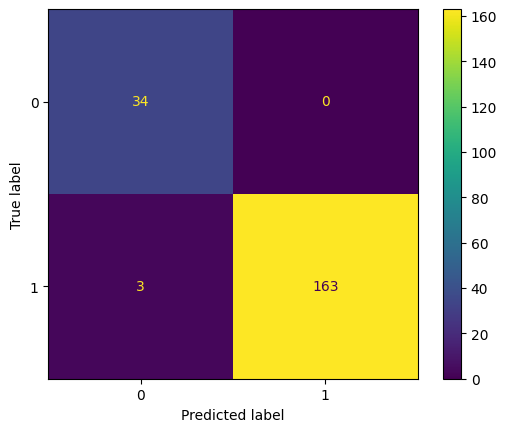

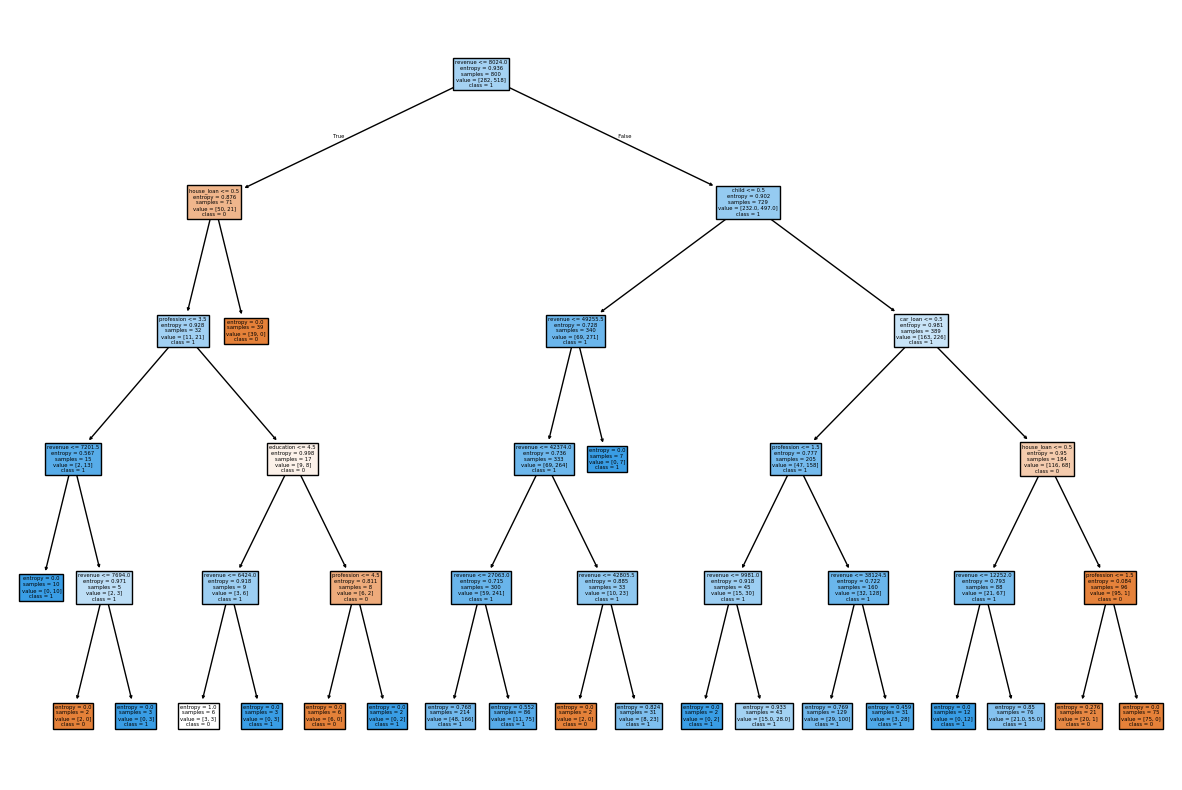

In [8]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_clf.classes_)
disp.plot()
plt.show()

plt.figure(figsize=(15, 10))
plot_tree(final_clf, feature_names=X_test.columns, class_names=['0', '1'], filled=True)
plt.savefig("task1_tree.png", dpi=200)
plt.show()

# 4. 任务二：手写 ID3

任务二统一采用：

- 离散特征、多叉树版 ID3
- `revenue` 需要先离散化
- 预测时要处理未见过属性值（fallback）


## 4.1 `revenue` 离散化


In [9]:
train_id3 = train_base.copy()
test_id3 = test_base.copy()

bins = [-np.inf, 10000, 20000, 30000, 40000, np.inf]
labels = ["<10k", "10k-20k", "20k-30k", "30k-40k", ">40k"]
train_id3["revenue"] = pd.cut(train_id3["revenue"], bins=bins, labels=labels).astype(str)
test_id3["revenue"] = pd.cut(test_id3["revenue"], bins=bins, labels=labels).astype(str)

## 4.2 核心函数骨架


In [10]:
import math

def calc_entropy(data, label="approve"):
    counts = data[label].value_counts()
    total = len(data)
    entropy = 0.0
    for count in counts:
        p = count / total
        entropy -= p * math.log2(p)
    return entropy

def calc_info_gain(data, feature, label="approve"):
    original_entropy = calc_entropy(data, label)
    total = len(data)
    parted_entropy = 0.0
    for val, sub_data in data.groupby(feature):
        weight = len(sub_data) / total
        parted_entropy += weight * calc_entropy(sub_data, label)
    return original_entropy - parted_entropy

def majority_class(data, label="approve"):
    return data[label].mode().iloc[0]

def build_tree(data, features, label="approve", max_depth=None, current_depth=0):
    node = {}
    node["majority"] = majority_class(data, label)
    
    if len(data[label].unique()) == 1:
        return data[label].unique()[0]
    
    if len(features) == 0 or (max_depth is not None and current_depth >= max_depth):
        return node["majority"]
    
    best_gain = -1.0
    best_feature = features[0]
    for feature in features:
        gain = calc_info_gain(data, feature, label)
        if gain > best_gain:
            best_gain = gain
            best_feature = feature
            
    node["split_feature"] = best_feature
    node["children"] = {}
    
    next_features = [f for f in features if f != best_feature]
    for val, sub_data in data.groupby(best_feature):
        node["children"][val] = build_tree(sub_data, next_features, label, max_depth, current_depth + 1)
        
    return node

def predict_one(tree, sample):
    if not isinstance(tree, dict):
        return tree
    feature = tree.get("split_feature")
    val = sample[feature]
    if val not in tree["children"]:
        return tree["majority"]
    return predict_one(tree["children"][val], sample)

def predict(tree, data):
    return [predict_one(tree, row) for _, row in data.iterrows()]

## 4.3 模型训练与测试集评估


In [11]:
id3_features = [c for c in train_id3.columns if c != "approve"]

tree = build_tree(train_id3, id3_features, "approve", max_depth=None)

y_true = test_id3["approve"].tolist()
y_pred_id3 = predict(tree, test_id3)

TP = sum(1 for yt, yp in zip(y_true, y_pred_id3) if yt == 1 and yp == 1)
TN = sum(1 for yt, yp in zip(y_true, y_pred_id3) if yt == 0 and yp == 0)
FP = sum(1 for yt, yp in zip(y_true, y_pred_id3) if yt == 0 and yp == 1)
FN = sum(1 for yt, yp in zip(y_true, y_pred_id3) if yt == 1 and yp == 0)

acc_id3 = (TP + TN) / (TP + TN + FP + FN)
prec_id3 = TP / (TP + FP) if (TP + FP) > 0 else 0
rec_id3 = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_id3 = 2 * prec_id3 * rec_id3 / (prec_id3 + rec_id3) if (prec_id3 + rec_id3) > 0 else 0

print(f"ID3 Confusion Matrix -> TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print("ID3 Accuracy:", acc_id3)
print("ID3 Precision:", prec_id3)
print("ID3 Recall:", rec_id3)
print("ID3 F1-Score:", f1_id3)

ID3 Confusion Matrix -> TP: 124, TN: 33, FP: 1, FN: 42
ID3 Accuracy: 0.785
ID3 Precision: 0.992
ID3 Recall: 0.7469879518072289
ID3 F1-Score: 0.852233676975945


## 4.4 选做题：预剪枝（可选）

选做题思路：

- 在 4.2 的 `build_tree` 函数中，已经预留了 `max_depth` 和 `current_depth`
- 基础任务中可以保持 `max_depth=None`，表示不限制树的最大深度
- 当 `max_depth is not None` 且 `current_depth >= max_depth` 时停止递归，返回当前多数类
- 递归构建子树时，将 `current_depth + 1` 传入下一层
- 比较 `max_depth = 3, 5, 10, None` 的结果


In [12]:
depths = [3, 5, 10, None]
for d in depths:
    t = build_tree(train_id3, id3_features, "approve", max_depth=d)
    preds = predict(t, test_id3)
    
    tp = sum(1 for yt, yp in zip(y_true, preds) if yt == 1 and yp == 1)
    tn = sum(1 for yt, yp in zip(y_true, preds) if yt == 0 and yp == 0)
    fp = sum(1 for yt, yp in zip(y_true, preds) if yt == 0 and yp == 1)
    fn = sum(1 for yt, yp in zip(y_true, preds) if yt == 1 and yp == 0)
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"Max Depth: {d} | Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")



Max Depth: 3 | Precision: 0.9879, Recall: 0.9819, F1: 0.9849
Max Depth: 5 | Precision: 0.9841, Recall: 0.7470, F1: 0.8493
Max Depth: 10 | Precision: 0.9920, Recall: 0.7470, F1: 0.8522
Max Depth: None | Precision: 0.9920, Recall: 0.7470, F1: 0.8522
